Plot saved as 'multi_file_bar_chart.png'


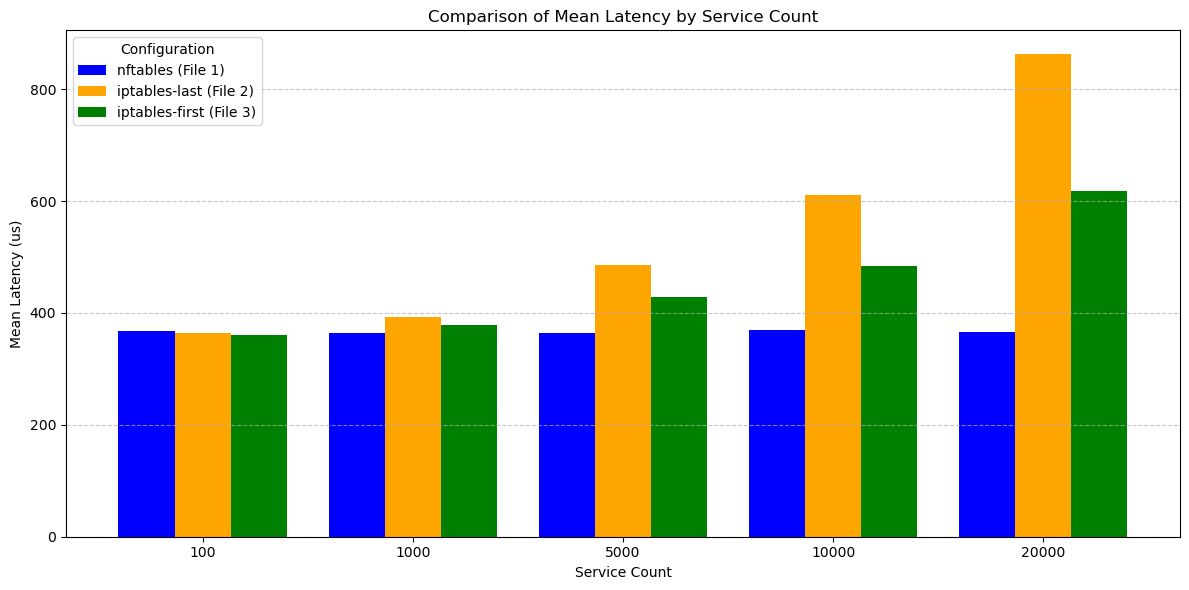

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# You can either manually specify run files:
files_to_plot = [
    {'filename': 'logs/dataplane/experiment_summary_20260225_073337.csv', 'label': 'nftables'},
    {'filename': 'logs/dataplane/experiment_summary_20260223_025149.csv', 'label': 'iptables-last'},
    {'filename': 'logs/dataplane/experiment_summary_20260223_041340.csv', 'label': 'iptables-first'}
]

# OR, uncomment this block to automatically find all summary files in logs/dataplane/
"""
all_summaries = glob.glob('logs/dataplane/experiment_summary_*.csv')
files_to_plot = []
for f in all_summaries:
    df_temp = pd.read_csv(f)
    if not df_temp.empty:
        mode = df_temp['ProxyMode'].iloc[0]
        pos = df_temp['WorkerPosition'].iloc[0]
        label = f"{mode}" if mode == 'nftables' else f"{mode} (pos:{pos})"
        files_to_plot.append({'filename': f, 'label': label})
"""

# Define colors for the labels
label_colors = {
    'nftables': 'blue',
    'iptables-last': 'orange',
    'iptables-first': 'green',
}

data_frames = []
colors = []

# Load and prepare data
for i, entry in enumerate(files_to_plot):
    filename = entry['filename']
    
    # Auto-fix path if user just put the raw csv name
    if not os.path.exists(filename) and os.path.exists(f"logs/dataplane/{filename}"):
        filename = f"logs/dataplane/{filename}"
        
    label = entry['label']
    
    try:
        # Load the CSV
        df = pd.read_csv(filename)
        
        if 'ServiceCount' in df.columns and 'MeanLatency_us' in df.columns:
            # Create a DataFrame for this file, indexed by ServiceCount
            unique_col_name = f"{label} (File {i + 1})"
            temp_df = df[['ServiceCount', 'MeanLatency_us']].copy()
            temp_df = temp_df.set_index('ServiceCount')
            temp_df.rename(columns={'MeanLatency_us': unique_col_name}, inplace=True)
            
            data_frames.append(temp_df)
            
            # Assign the color based on the label
            colors.append(label_colors.get(label, 'gray'))
        else:
            print(f"Skipping {filename}: Required columns not found.")
            
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")

if data_frames:
    # Combine all dataframes into one side-by-side table
    combined_df = pd.concat(data_frames, axis=1)
    
    # Sort by ServiceCount (Index)
    combined_df.sort_index(inplace=True)
    
    # Create the grouped bar chart
    ax = combined_df.plot(kind='bar', figsize=(12, 6), color=colors, width=0.8)
    
    plt.xlabel('Service Count')
    plt.ylabel('Mean Latency (us)')
    plt.title('Comparison of Mean Latency by Service Count')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0) # Keep x-axis labels horizontal
    plt.legend(title="Configuration")
    
    plt.tight_layout()
    plt.savefig('multi_file_bar_chart.png')
    print("Plot saved as 'multi_file_bar_chart.png'")
else:
    print("No valid data found to plot.")

P50 plot saved as 'p50_latency_bar_chart.png'


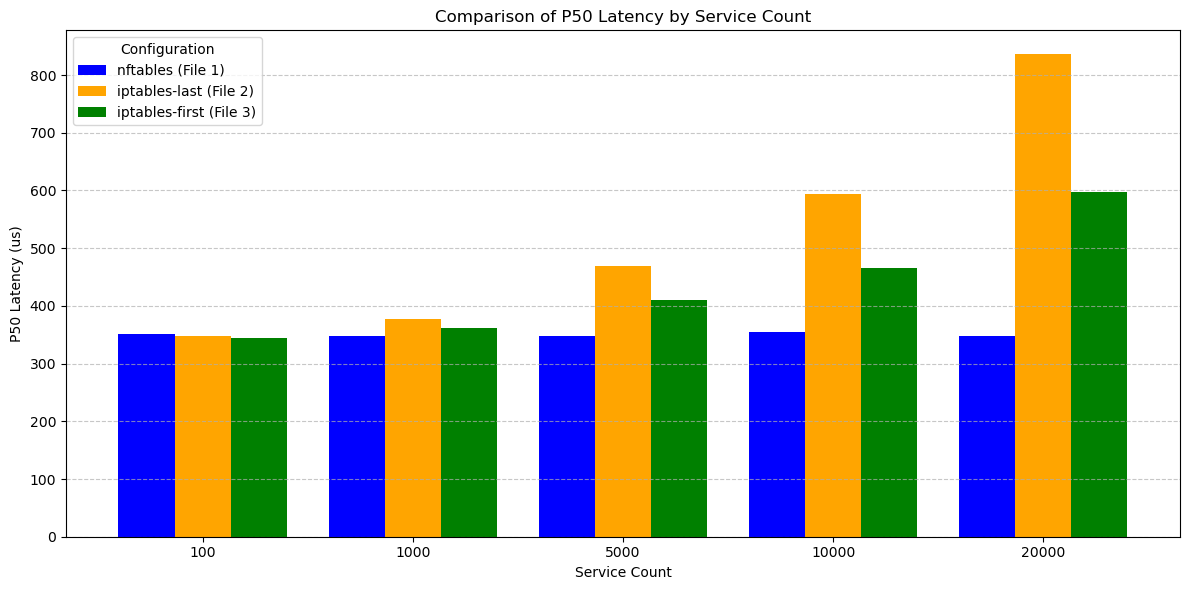

In [6]:
# Generate P50 Latency Graph
p50_data_frames = []
p50_colors = []

for i, entry in enumerate(files_to_plot):
    filename = entry['filename']
    label = entry['label']
    
    try:
        df = pd.read_csv(filename)
        
        if 'ServiceCount' in df.columns and 'P50_us' in df.columns:
            unique_col_name = f"{label} (File {i + 1})"
            temp_df = df[['ServiceCount', 'P50_us']].copy()
            temp_df = temp_df.set_index('ServiceCount')
            temp_df.rename(columns={'P50_us': unique_col_name}, inplace=True)
            
            p50_data_frames.append(temp_df)
            p50_colors.append(label_colors.get(label, 'gray'))
        else:
            print(f"Skipping {filename}: P50_us column not found.")
            
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")

if p50_data_frames:
    combined_p50_df = pd.concat(p50_data_frames, axis=1)
    combined_p50_df.sort_index(inplace=True)
    
    ax = combined_p50_df.plot(kind='bar', figsize=(12, 6), color=p50_colors, width=0.8)
    
    plt.xlabel('Service Count')
    plt.ylabel('P50 Latency (us)')
    plt.title('Comparison of P50 Latency by Service Count')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0)
    plt.legend(title="Configuration")
    
    plt.tight_layout()
    plt.savefig('p50_latency_bar_chart.png')
    print("P50 plot saved as 'p50_latency_bar_chart.png'")
    plt.show()
else:
    print("No valid P50 data found to plot.")

P95 plot saved as 'p95_latency_bar_chart.png'


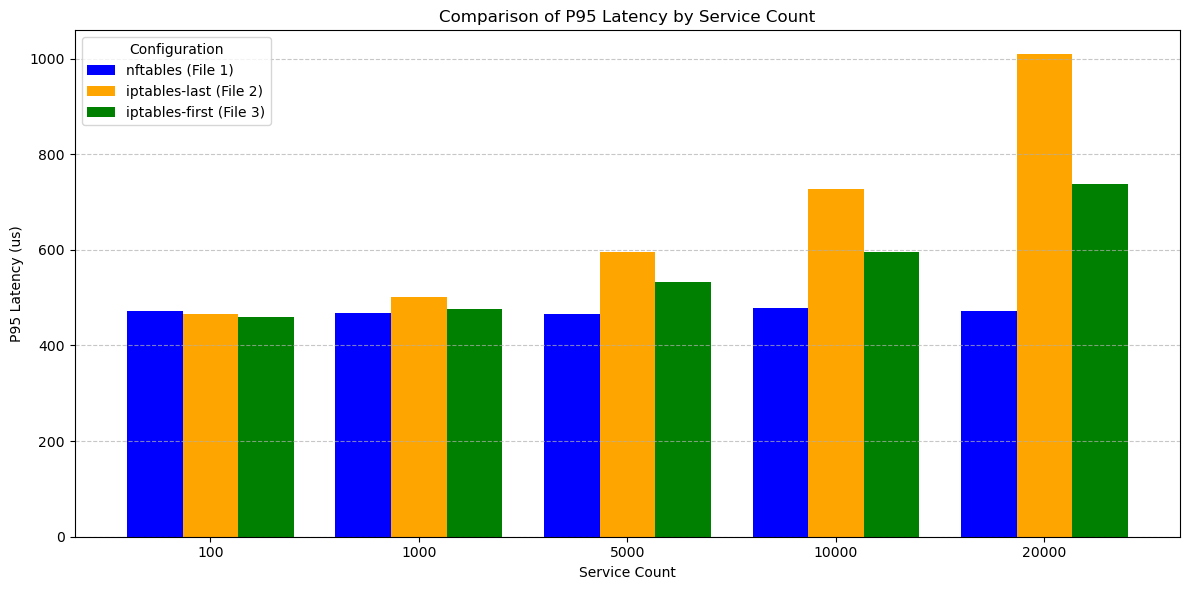

In [7]:
# Generate P95 Latency Graph
p95_data_frames = []
p95_colors = []

for i, entry in enumerate(files_to_plot):
    filename = entry['filename']
    label = entry['label']
    
    try:
        df = pd.read_csv(filename)
        
        if 'ServiceCount' in df.columns and 'P95_us' in df.columns:
            unique_col_name = f"{label} (File {i + 1})"
            temp_df = df[['ServiceCount', 'P95_us']].copy()
            temp_df = temp_df.set_index('ServiceCount')
            temp_df.rename(columns={'P95_us': unique_col_name}, inplace=True)
            
            p95_data_frames.append(temp_df)
            p95_colors.append(label_colors.get(label, 'gray'))
        else:
            print(f"Skipping {filename}: P95_us column not found.")
            
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")

if p95_data_frames:
    combined_p95_df = pd.concat(p95_data_frames, axis=1)
    combined_p95_df.sort_index(inplace=True)
    
    ax = combined_p95_df.plot(kind='bar', figsize=(12, 6), color=p95_colors, width=0.8)
    
    plt.xlabel('Service Count')
    plt.ylabel('P95 Latency (us)')
    plt.title('Comparison of P95 Latency by Service Count')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0)
    plt.legend(title="Configuration")
    
    plt.tight_layout()
    plt.savefig('p95_latency_bar_chart.png')
    print("P95 plot saved as 'p95_latency_bar_chart.png'")
    plt.show()
else:
    print("No valid P95 data found to plot.")

In [ ]:
import re

# Generate CPU Utilization Graph for Normal Experiment
cpu_data_frames = []
cpu_colors = []

for i, entry in enumerate(files_to_plot):
    filename = entry['filename']
    
    if not os.path.exists(filename) and os.path.exists(f"logs/dataplane/{filename}"):
        filename = f"logs/dataplane/{filename}"
        
    label = entry['label']
    
    try:
        # We need the timestamp to find the corresponding CPU files
        # Format is typically experiment_summary_YYYYMMDD_HHMMSS.csv
        match = re.search(r'experiment_summary_(\d{8}_\d{6})\.csv', filename)
        if match:
            timestamp = match.group(1)
            
            # Find all CPU logs for this specific run
            cpu_logs = glob.glob(f"logs/dataplane/cpu_PM_*_SC_*_{timestamp}.csv")
            
            if cpu_logs:
                service_cpu_map = {}
                for cpu_log in cpu_logs:
                    # Extract the ServiceCount from the CPU filename
                    sc_match = re.search(r'_SC_(\d+)_', cpu_log)
                    if sc_match:
                        svc_count = int(sc_match.group(1))
                        df_cpu = pd.read_csv(cpu_log)
                        
                        if not df_cpu.empty:
                            # Average CPU across the test duration for the worker node(s)
                            avg_cpu = df_cpu['CPU_Percent'].mean()
                            service_cpu_map[svc_count] = avg_cpu
                            
                if service_cpu_map:
                    temp_df = pd.DataFrame(list(service_cpu_map.items()), columns=['ServiceCount', 'CPU_Percent'])
                    temp_df.set_index('ServiceCount', inplace=True)
                    
                    unique_col_name = f"{label} (File {i + 1})"
                    temp_df.rename(columns={'CPU_Percent': unique_col_name}, inplace=True)
                    
                    cpu_data_frames.append(temp_df)
                    cpu_colors.append(label_colors.get(label, 'gray'))
            else:
                print(f"No CPU files found for {filename}")
        else:
            print(f"Could not extract timestamp from {filename}")
            
    except Exception as e:
        print(f"Error processing CPU logs for '{filename}': {e}")

if cpu_data_frames:
    combined_cpu_df = pd.concat(cpu_data_frames, axis=1)
    combined_cpu_df.sort_index(inplace=True)
    
    ax = combined_cpu_df.plot(kind='bar', figsize=(12, 6), color=cpu_colors, width=0.8)
    
    plt.xlabel('Service Count')
    plt.ylabel('Average CPU Utilization (%)')
    plt.title('Comparison of CPU Utilization by Service Count')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0)
    plt.legend(title="Configuration")
    
    plt.tight_layout()
    plt.savefig('cpu_utilization_bar_chart.png')
    print("CPU plot saved as 'cpu_utilization_bar_chart.png'")
    plt.show()
else:
    print("No valid CPU data found to plot for normal experiments.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Configuration for plotting CPU utilization and Throughput
throughput_files = glob.glob('logs/throughput/throughput_summary_*.csv')

if throughput_files:
    latest_throughput_file = max(throughput_files, key=os.path.getctime)
    df_throughput = pd.read_csv(latest_throughput_file)
    
    # Sort by RPS
    df_throughput = df_throughput.sort_values(by='RPS')
    
    # Extract timestamp to find corresponding CPU files
    timestamp = latest_throughput_file.split('_')[-1].replace('.csv', '')
    proxy_mode = df_throughput['ProxyMode'].iloc[0]
    service_count = df_throughput['ServiceCount'].iloc[0]
    
    # 1. Plot Throughput vs Latency
    plt.figure(figsize=(10, 6))
    plt.plot(df_throughput['RPS'], df_throughput['P50_us'], marker='o', label='P50')
    plt.plot(df_throughput['RPS'], df_throughput['P95_us'], marker='s', label='P95')
    plt.plot(df_throughput['RPS'], df_throughput['P99_us'], marker='^', label='P99')
    plt.xlabel('Requests per Second (RPS)')
    plt.ylabel('Latency (us)')
    plt.title(f'Latency vs RPS ({proxy_mode}, {service_count} services)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('latency_vs_rps.png')
    plt.show()
    
    # 2. Process and Plot CPU Utilization
    cpu_files = glob.glob(f'logs/throughput/cpu_PM_{proxy_mode}_SC_{service_count}_RPS_*_{timestamp}.csv')
    
    if cpu_files:
        print(f"Found {len(cpu_files)} CPU metric files.")
        cpu_data = []
        for file in cpu_files:
            # Extract RPS from filename
            parts = os.path.basename(file).split('_')
            rps_idx = parts.index('RPS') + 1
            rps_val = int(parts[rps_idx])
            
            df_cpu = pd.read_csv(file)
            if not df_cpu.empty:
                # Calculate mean CPU across nodes, or sum if we want cluster total
                # Usually we care about the worker node or average
                mean_cpu = df_cpu.groupby('Node')['CPU_Percent'].mean().reset_index()
                mean_cpu['RPS'] = rps_val
                cpu_data.append(mean_cpu)
        
        if cpu_data:
            df_all_cpu = pd.concat(cpu_data)
            
            plt.figure(figsize=(10, 6))
            for node in df_all_cpu['Node'].unique():
                node_data = df_all_cpu[df_all_cpu['Node'] == node].sort_values(by='RPS')
                plt.plot(node_data['RPS'], node_data['CPU_Percent'], marker='o', label=node)
                
            plt.xlabel('Requests per Second (RPS)')
            plt.ylabel('Average CPU Utilization (%)')
            plt.title(f'CPU Utilization vs RPS ({proxy_mode}, {service_count} services)')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig('cpu_vs_rps.png')
            plt.show()
        else:
            print("No valid CPU data found in the files.")
    else:
        print(f"No CPU files found matching pattern logs/throughput/cpu_PM_{proxy_mode}_SC_{service_count}_RPS_*_{timestamp}.csv")
else:
    print("No throughput summary files found in logs/throughput/")